# The risks of (mis)timing an exponential: a minimal model of disease control under uncertainty

[Dylan H. Morris](http://dylanhmorris.com) and [Fernando W. Rossine](https://scholar.princeton.edu/ctarnita/people/fernando-rossine) <br>
Department of Ecology & Evolutionary Biology <br>
Princeton University, Princeton, NJ, USA <br>
17 March 2020

# Introduction

The following model was inspired by the debates surrounding the United Kingdom Government's [initial strategy](https://www.theatlantic.com/health/archive/2020/03/coronavirus-pandemic-herd-immunity-uk-boris-johnson/608065/) for addressing the COVID-19 pandemic. 

## The debate
The UK's proposed approach, [prior to a policy change announced yesterday](https://www.bbc.com/news/health-51915302), was based on three assumptions:
1. Restrictive disease control measures carry social and economic cost
2. Even leaving aside cost, the most restrictive measures can only be maintained for short periods before compliance becomes a problem.
3. Individuals who are infected with COVID-19 and recover [become immune, at least temporarily](http://dylanhmorris.com/post/immunity-primer), and will not be reinfected during the epidemic.

There is little disagreement about the first or third assumptions. The degree to which the second assumption holds has been a matter of some debate, but it is plausible that it holds at least to some degree for a sufficiently long and arduous intervention.

Given these assumptions, the UK Government determined that the most restrictive and effective control measures should not be imposed immediately. They should instead be used during a period of rapid epidemic expansion, thus maximizing the number of cases averted and avoiding a large second epidemic peak after the relaxation of control measures. 

Indeed, some discussion surrounding the plan have highlighted the risk of intervening too strongly too early and then backing off too much. An aggressive response that causes a transient decline in total cases but fails to eradicate a disease fully can lead to an [explosive second epidemic peak](https://personalpages.manchester.ac.uk/staff/thomas.house/blog/modelling-herd-immunity.html). This occurs because the overly aggressive intervention slows the accumulation of immunity to the disease in the population. When measures are relaxed, many individuals remain susceptible, and the number of infections can grow rapidly.

We believe, however, that there there are potential dangers in keeping disease-control powder dry in the name of maximizing efficacy and minimizing the risk of resurgence. In particular, we are concerned about imperfect implementation, whether due to noisy estimates of case counts, errors in epidemiological parameter estimation, or unplanned delays in policy implementation. In the case of explosive epidemic of a novel pathogen, imperfect implementation of this strategy can produce extreme costs. This is due to an asymmetry between underreaction or acting too late and overreaction or acting too early: only overreaction leaves sufficent time and resources for a course-correction.

## The problem: exponential growth magnifies errors
During the initial epidemic spread of a novel zoonotic disease like COVID-19 – a disease to which almost no-one in the population is immune – infectious cases increase near-exponentially.

Exponential growth magnifies implementation errors. If an intervention that is too little or too late, there may not be time to course-correct before the epidemic spikes to a large peak number of infectious individuals. If there is an insufficiently controlled epidemic peak, [hospitals and emergency services can be overwhelmed](https://www.statnews.com/2020/03/11/flattening-curve-coronavirus/), case-fatality rates rise, and the overall epidemic morbidity and mortality rise dramatically. Social and economic costs are also magnified.

Since verbal arguments do not always stand up to more rigorous analysis, we have developed a simple mathematical model to encode the basic problem of an optimal short intervention aimed and reducing the highest peak in an epidemic.


## This blog post
We aim here at a semi-technical presentation of our work. We wish to provide sufficient detail – and code – to allow researchers to assess the work. But as this is a blog post, we will try to provide enough guidance for the non-technical reader to make things accessible. That said, this is not intended as a tutorial on epidemiological modeling, and some sections (in particular the specification and analysis of the mathematical model) are somewhat dense and technical. A number of particularly technical points are deferred to a technical appendix at the end of the post.

# Model

## Aim: peak reduction

The strategies being debated aim to maximize the benefits from a highly efficacious intervention that can only be maintained for a limited time. To assess the risks of mis-implementing such a strategy, we first specify the goal to be accomplished and determine an optimal strategy. We then assess the costs of aiming at but mis-implementing such an optimal strategy.

We will consider strategies that aim at epidemic mitigation rather than at eradication, as these have been the focus of the current discussions. Moreover, eradication of a pathogen with $\mathcal{R}_e \gg 1$ in the absence of control requires a sustained strong response that holds $\mathcal{R}_e < 1$ for a substantial amount of time. Since this work focuses on interventions that are constrained to be short, limited in efficacy, or both, we will assume policymakers are aiming at mitigation – ["flattening the curve"](https://www.statnews.com/2020/03/11/flattening-curve-coronavirus/)

As such, our principal criterion for the success of an intervention will be **minimizing the highest peak of the epidemic**. The peak is the largest single quantity of infectious individuals at any one time. This quantity is critical because it is the point at which [hospital beds will be most in demand](https://www.vox.com/science-and-health/2020/3/14/21179714/coronavirus-covid-19-hospital-beds-china) and health services will be most strained. An overwhelmed system can dramatically increase case-fatality rates and lead to increased rates of complications from infection. 

All else equal, a policymaker would also like to minimize the **total cases** during the epidemic, but for an explosively spreading novel virus, this consideration is secondary. The costs of a healthcare system collapse are simply too high. What is more, among non-eradicative interventions, those that reduce the highest epidemic peak (almost) necessarily reduce the total case count (or "final size") of the epidemic, though they may not do so as effectively as interventions specifically targeted at final size reduction rather than at peak reduction.

To get some intuition for the points above, let's plot an the classic SIR (susceptible-infectious-recovered) model of an epidemic with COVID-like parameters, optimistically imagining that the healthcare system has a capacity to handle up to 20% of the population being infected at any one time.

In [1]:
## import needed modules
from scipy.optimize import minimize
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from IPython.display import set_matplotlib_formats

## styling for plots
set_matplotlib_formats('svg')
plt.style.use('seaborn-whitegrid')
mpl.rcParams['axes.labelsize'] = "xx-large"
mpl.rcParams['xtick.labelsize'] = "xx-large"
mpl.rcParams['ytick.labelsize'] = "xx-large"
mpl.rcParams['axes.titlesize'] = "xx-large"
mpl.rcParams['text.usetex'] = True
mpl.rcParams['axes.formatter.use_mathtext'] = True
mpl.rcParams['axes.formatter.limits'] = ((-3, 3))
mpl.rcParams['axes.grid'] = True
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.framealpha'] = 1
mpl.rcParams['legend.title_fontsize'] = "x-large"
mpl.rcParams['legend.fontsize'] = "x-large"
mpl.rcParams['lines.linewidth'] = 5

## custom colors
ourblue = "#0571a3"
ourred = "#c20a1f"

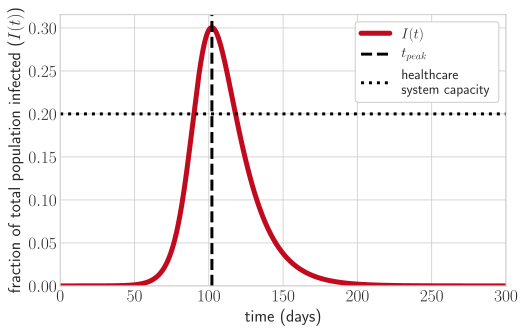

In [2]:
## solve and plot the SIR model 
def deriv(state, time, beta, gamma):
    S, I, R = state
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    
    return np.array([dS, dI, dR])

## parameters
R_0 = 3 # basic reproduction number
gamma = 1 / 14 # average recovery time of 2 weeks
beta = R_0 * gamma # contact rate
I0 = 1e-6 # small seeding fraction of the population infectious, otherwise fully susceptible population
hs_capacity = 0.2
S0 = 1 - I0
inits = np.array([S0, I0, 0])
times = np.linspace(0, 300, 1000)

results = odeint(deriv, inits, times, (beta, gamma))

fig, axis = plt.subplots(figsize = (8, 5))
axis.plot(times, results[:, 1], label = "$I(t)$", color = ourred)
t_peak = times[np.argmax(results[:, 1])]
axis.axvline(t_peak, label = "$t_{peak}$", lw = 3, ls = "dashed", color = "black")
axis.axhline(hs_capacity, label = "healthcare\nsystem capacity", lw = 3, ls = "dotted", color = "black")
axis.set_xlabel("time (days)")
axis.set_ylabel("fraction of total population infected ($I(t)$)")
axis.set_ylim(bottom = 0)
axis.set_xlim(left = 0, right = 300)
axis.legend()

## Goal: an optimal peak reduction strategy

Given absolutely perfect and complete information, what would be the optimal single-shot strong intervention for reducing the height of the epidemic peak?  

The peak is achieved when the $\mathcal{R}_e = 1$; that is, when new infections exactly balance recoveries. This point can be hastened – and the number of infections at that point thereby reduced – if the number of susceptible individuals in the population is depleted. This is one benefit of vaccination, when possible. We can see this by starting our epidemic model with some portion of the population already immune:

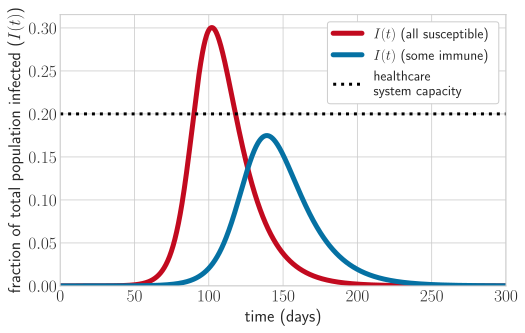

In [3]:
## lets make some individuals immunie before the epidemic starts
I0 = 1e-6 ## neglible initial fraction infected
Imm0 = 0.2  ## 20% initially immune
S0 = 1 - I0 - Imm0 ## rest susceptible
inits_deplete = np.array([S0, I0, Imm0])

results_deplete = odeint(deriv, inits_deplete, times, (beta, gamma))

fig, axis = plt.subplots(figsize = (8, 5))
axis.plot(times, results[:, 1], label = "$I(t)$ (all susceptible)", color = ourred)
axis.plot(times, results_deplete[:, 1], label = "$I(t)$ (some immune)", color = ourblue)
axis.axhline(hs_capacity, label = "healthcare\nsystem capacity", lw = 3, ls = "dotted", color = "black")
axis.set_xlabel("time (days)")
axis.set_ylabel("fraction of total population infected ($I(t)$)")
axis.set_ylim(bottom = 0)
axis.set_xlim(left = 0, right = 300)
axis.legend()

When infection and recovery brings with it immunity, as we [strongly suspect is the case for COVID-19](http://dylanhmorris.com/post/immunity-primer/), the disease is eventually self-limiting. It runs out of susceptible individuals to infect. Locking down an epidemic too early and aggressively slows depletion of susceptibles. If controls are then relaxed too soon, there can be a large second epidemic peak, as we can see by modeling such an overly aggressive early reaction:

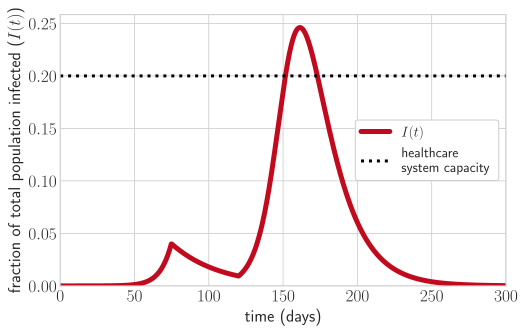

In [4]:
I0 = 1e-6 ## neglible initial fraction infected
S0 = 1 - I0 ## rest susceptible
inits_before = np.array([S0, I0, 0])

times_before = times[:250]
times_lockdown = times[250:400]
times_after = times[400:]

results_before = odeint(deriv, inits_before, times_before, (beta, gamma))
inits_lockdown = results_before[-1]
## beta reduced during the short-lived lockdown...
results_lockdown = odeint(deriv, inits_lockdown, times_lockdown, (beta * 0.2, gamma))
inits_after = results_lockdown[-1]
## then epidemic comes roaring back
results_after = odeint(deriv, inits_after, times_after, (beta, gamma))

results_all = np.concatenate([results_before, results_lockdown, results_after])

fig, axis = plt.subplots(figsize = (8, 5))
axis.plot(times, results_all[:, 1], label = "$I(t)$", color = ourred)
axis.axhline(hs_capacity, label = "healthcare\nsystem capacity", lw = 3, ls = "dotted", color = "black")
axis.set_xlabel("time (days)")
axis.set_ylabel("fraction of total population infected ($I(t)$)")
axis.set_ylim(bottom = 0)
axis.set_xlim(left = 0, right = 300)
axis.legend()

When intervening, then, our aim should be to deplete susceptibles as rapidly as possible during the intervention while limiting the growth of the infection. To model this, we first need to specifiy an epidemic model.

## Epidemic model: well-mixed SIR

For simplicity, we consider a susceptible-infectious-recovered (SIR) model. We keep track of the fractions of susceptible ($S$), infectious ($I$) and recovered ($R$) individuals in the population (so $S+I+R=1$). The rates of change of these fractions in time are given by a set of differential equations:

\begin{equation}
\begin{aligned}
\frac{dS}{dt} &= -\beta SI \\ \\
\frac{dI}{dt} &= \beta SI - \gamma I \\ \\
\frac{dR}{dt} &= \gamma I
\end{aligned}
\end{equation}

Susceptible individuals in class $S$ are infected at a rate proportional to the current fraction of infectious individuals $I$ with a proportionality constant $\beta$. Infectious individuals recover at a rate $\gamma$ and are subsequently immune. On average, each infectious individual remains infectious for $\frac{1}{\gamma}$ time units and inoculates $\beta$ individuals during that time, of whom a fraction $S$ are susceptible and themselves become infected. This gives us a basic reproduction number $\mathcal{R}_0$ (the average number of inoculations caused by each infectious individual prior to recovery) of 

$$\mathcal{R}_0 = \frac{\beta}{\gamma}$$

and an effective reproduction number $\mathcal{R}_e$ (the average number of successful infections caused by each infectious individual prior to recovery) of

$$\mathcal{R}_e = \frac{\beta}{\gamma} S$$


For simplicity, we ignore births and deaths. That said, net births and deaths do not meaningfully affect the epidemic dynamics for an epidemic propagating with the speed and the case-fatality rate of COVID-19. 

A reminder: COVID-19 is dangerous not so much because the overall case fatality rate is particularly high, but because it threatens to cause _so many cases_ that even at a low case fatality rate, there will be substantial total mortality.

## Strategy

Given this model and given limited amount of time $\tau$ for which we can intervene aggressively, we take the following strategy: intervene to tune $\beta$ continuously in time so that $\mathcal{R}_e(t) = \frac{\beta(t)}{\gamma}S(t)$ is held fixed at 1. 

This implies 

$$\beta(t) = \frac{\gamma}{S(t)}$$

Because $\mathcal{R}_e(t)$ is held fixed at 1, $I(t)$ will remain fixed during the intervention at a value $I_i$. Susceptibles will be depleted at a rate $\gamma I_i$ (since we are holding $\mathcal{R}_e = 1$ and $\frac{dI}{dt} = 0$, we must have $\beta SI = \gamma I$).

This strategy has thus has the effect of "freezing" the number of infectious individuals at some fixed level $I(t) = I_i$. We are able to deplete the pool of susceptible individuals rapidly while preventing the epidemic from growing further. Here is an example, which requires a bit of setup code:

In [5]:
## set up functions for numerically
## integrating our model with the 
## R_e = 1 intervention at I_i

def deriv(state, time, beta, gamma, **args):
    """
    time derivative of our system
    in the absence of intervention
    """
    S, I, R = state
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    
    return np.array([dS, dI, dR])

def interven_deriv(state, time, beta, gamma, **args):
    """
    time derivative of our
    system during intevention
    """
    S, I, R = state
    
    b = gamma / S
    
    if b < beta:
        dS = -gamma * I
        dI = 0
        dR = gamma * I
    
    else:
        dS = -beta * S * I
        dI = beta * S * I - gamma * I
        dR = gamma * I
        
    return np.array([dS, dI, dR])

def calc_interv_timecourse_I_i(
    R0, gamma, tau, I_i, 
    times = np.linspace(0, 20, 1000),
    inits = np.array([1 - 1e-6, 1e-6, 0]),
    interven_deriv = interven_deriv,
    no_interven_deriv = deriv,
    c = 1):
    
    """
    Solve the SIR model with and 
    without a specified R_e = 1 intervention
    """

    beta = R0 * gamma
    
    no_intervention = odeint(deriv, 
                             inits, 
                             times, 
                             (beta, gamma, c))
    
    t_interv_ind = np.argmax(no_intervention[:, 1] >= I_i) - 1
    
    if t_interv_ind > 0:
        
        ## when does the intervention happen, and when does it end
        t_interv = times[t_interv_ind]
        t_end_interv = t_interv + tau
    
        ## what time index corresponds to the end
        t_end_interv_ind = np.argmax(times >= t_end_interv) - 1

        interv_inits = no_intervention[t_interv_ind]

        before_intervention = no_intervention[:t_interv_ind]
        during_intervention = odeint(interven_deriv, interv_inits, 
                                  times[t_interv_ind:t_end_interv_ind],
                                  (beta, gamma))

        if len(during_intervention) > 0:
            after_inits = during_intervention[-1]
        else:
            after_inits = interv_inits
        
        after_intervention = odeint(deriv, after_inits, times[t_end_interv_ind:], (beta, gamma))
    
        inter_results = np.concatenate(
                [before_intervention,
                 during_intervention,
                 after_intervention])

    else:
        inter_results = no_intervention
        
    return (no_intervention, inter_results)

## Example of our control strategy

We plot an example usage of our control strategy. We intervene when 15% percent of individuals in the population are infectious ($I_i = 0.15$).

Text(0, 0.5, 'fraction of population infected ($I(t)$)')

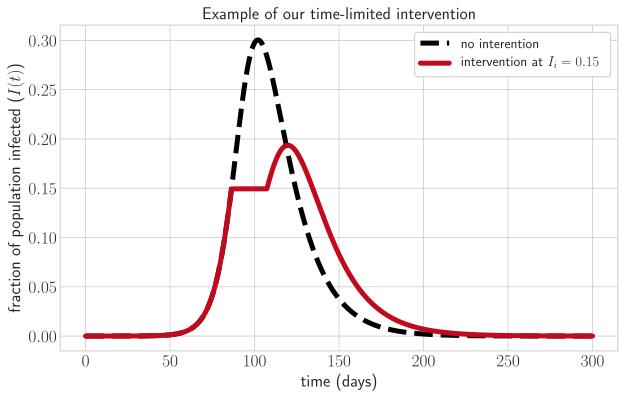

In [6]:
## calculate SIR model with intervention
R0_ex = 3
gamma_ex = 1/14
tau_ex = 21
I_i_ex = .15
times = np.linspace(0, 300, 5000)

no_inv, inv = calc_interv_timecourse_I_i(
    R0_ex, 
    gamma_ex, 
    tau_ex, 
    I_i_ex, 
    times = times)

lw = 5
fig, axis = plt.subplots(figsize = (10, 6))

# plot curve in absence of intervention
axis.plot(
    times, 
    no_inv[:,1], 
    lw = lw,
    label = "no interention",
    color = "black",
    ls = "dashed")

# plot curve with intervention at I_i = 0.15
axis.plot(
    times, 
    inv[:,1], 
    linestyle = "solid",
    lw = lw,
    label = "intervention at $I_i = 0.15$",
    color = ourred)

axis.legend()
axis.set_title("Example of our time-limited intervention")
axis.set_xlabel("time (days)")
axis.set_ylabel("fraction of population infected ($I(t)$)")

### Remark: (non)-feasibility
We note here that this would be an impossible strategy in practice. It requires continuous and instantaneous policy intervention to tune the value of $\beta$ to match the changing fraction of susceptibles $S(t)$. It also assumes that the value of $\beta$ can always feasibly be reduced to exactly $\frac{\gamma}{S(t)}$. 

Our aim in designing this strategy is to be as generous as possible in our estimates of the efficacy of a limited time intensive intervention. We will proceed to show that even an optimal intervention is extremely liable to failure if it is mistimed. 

# Model of peak reduction via intervention
We now use this strategy with the aim of reducing $I_\text{max}$, the peak (largest) value of $I(t)$ during the epidemic.

Suppose we start this intervention with some quantities $S_i$, $I_i$, and $R_i$ of susceptible, infectious and recovered individuals at a time $t_i$. Over the course of our intervention, $\frac{dS}{dt}$ will then be constant at a value:

$$\frac{dS}{dt} = -\beta(t) S I_i = \gamma I_i$$

If we continue the intervention for $\tau$ units of time, then during the intervention we deplete a total number of susceptibles given by:

$$\Delta S =  I_i \gamma\tau$$

A [known result](http://mat.uab.cat/matmat/PDFv2013/v2013n03.pdf) in epidemiological theory holds that the maximum number of infectious individuals achieved during an SIR epidemic during the time window $t = t_x$ to $t = \infty$ is given by:

$$I_\text{window max}(t_x) = I(t_x) + S(t_x) - \frac{1}{\mathcal{R}_x}\log\Big(S(t_x)\Big) - \frac{1}{\mathcal{R}_0} + \frac{1}{\mathcal{R}_0} \log\Big(\frac{1}{\mathcal{R}_0}\Big)$$

The overall maximum is of course $I_\text{window max}(0)$, which we will call simply $I_\text{max}$.

Denote by $I_\text{peak}$ the value of $I_\text{max}$ the absence of any intervention:

$$I_\text{peak} = 1 - \frac{1}{\mathcal{R}_0} + \frac{1}{\mathcal{R}_0} \log\Big(\frac{1}{\mathcal{R}_0}\Big)$$

By our assumptions about the intervention strategy:

\begin{equation}
\begin{aligned}
I(t_i + \tau) &= I_i \\ \\
S(t_i + \tau) &= S_i - \Delta S
\end{aligned}
\end{equation}

So:
$$I_\text{window max}(t_i + \tau) = I_i + S_i - \Delta S - \frac{1}{\mathcal{R}_0}\log\Big(S_i - \Delta S \Big) - \frac{1}{\mathcal{R}_0} + \frac{1}{\mathcal{R}_0} \log\Big(\frac{1}{\mathcal{R}_0}\Big)$$

Maximizing susceptibles depleted during our intervention is crucial to reducing $I_\text{window max}(t_i + \tau)$ and thus reducing the overall $I_\text{max}$. It can be shown (see technical appendix) that an optimal interention will always have $I_\max = I_\text{window max}(t_i + \tau)$. That is the peak of the epidemic occurs after the intervention. The intuition is that if the peak occurs before or during the intervention, we should intervene either earlier, more strongly, or both.

It can also be shown (see appendix) that when comparing two interventions that start at $I_i, S_i$, the intervention that ends with lower $S_e$ will have lower $I_\text{window max}(t_i + \tau)$. Taken together, these two results give us some intuition: the strength of our intervention is in achieving the largest possible $\Delta S$ that does not permit the epidemic to *grow* during the intervention.

### Remark: dimensionality 
This is a two-parameter model in terms of $\mathcal{R}_0$, the reproduction number of the disease, and the product $\gamma \tau$, the efficacy of the intervention, measured in terms of susceptibles removed per infectious individual.

# Optimizing the intervention to achieve the largest possible peak reduction

Given $\tau$, $\mathcal{R}_0$, and $\gamma$, we can find an optimal point of intervention $I_i = I_\text{opt}$ that minimizes $I_\text{max}$.  Note that any optimal value of $I_i$ must satisfy $I_i \le I_\text{peak}$, otherwise we will simply have $I_{\max} = I_\text{peak}$, which is maximally suboptimal.

How much better is the optimum intervention than suboptimal ones? How much better is it than doing nothing?

We cannot solve this analytically (though it can be approximated), but it is also simple and illuminating simply to solve numerically for $I_\max(I_i)$ simply by numerically integrating the SIR model first until $I(t) = I_i$, then integrating with our intervention (or simply calculating it) until $t = t_i + \tau$, and then integrating forward from there. 

As noted, we show in the technical appendix that an optimal intervention will always permit some degree of post-intervention peak. Infections will rise (though often very briefly) after the intervention ceases to a much-reduced peak $I_\text{max}$, and then fall. 

In the interest of rapid respsonse, we have not performed or visualized broad parameter sweeps. But the interested reader can run the code for themself and see that the qualitative effects we find are extremely robust to variation in parameters.

To calculate and visualize our numerical results, we need some additional helper code:

In [7]:
def get_peak(R0, S0 = 1, I0 = 0):
    """
    get the value of I(t) at the 
    peak of an epidemic
    """
    return (S0 + I0 - 
            (1/R0) * np.log(S0) - 
            (1/R0) + 
            (1/R0) * np.log(1/R0))


def I_max_exact(
    I_i,
    R0,
    gamma,
    tau,
    inits = [1 - 1e-8, 1e-8, 0],
    max_time = 1000, fineness = 10000):
    
    if I_i == 0:
        return get_peak(R0)
    else:
        times = np.linspace(0, max_time, fineness)
        no_inv, inv = calc_interv_timecourse_I_i(
            R0, gamma, tau, I_i,
            inits = inits,
            times = times)
    
        return np.max(inv[:, 1])
    

def I_opt(R0, gamma, tau, fineness = 1000):
    """
    find the value of I_i that
    minimizes I_max
    """
    vals = np.linspace(0, 1, fineness)
    I_maxes = [I_max_exact(val, R0, gamma, tau) for val in vals]
    ind_I_max = np.argmin(I_maxes)
    return vals[ind_I_max]


# How many infections should we allow before intervention in order to minimize the peak?

We calculate and plot $I_\text{max}$ as a function of $I_i$: the number of infectious individuals when we intervene. We see that there is a clear optimal value of $I_i$, which we call $I_\text{opt}$. Intervening at $I_\text{opt}$ minimizes the value of $I_\text{max}$.

Text(0.5, 0.98, 'Peak incidence $I_{\\max}$ as a function of intervention point $I_i$')

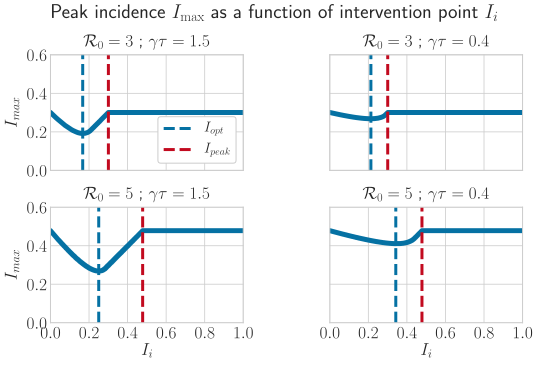

In [8]:
## COVID-like parameters, which we will
## use throughout, for consistency,
## unless otherwise specified
R0_raw = 3
gamma_raw = 1/14
tau_raw = 21

## other parameters, for comparison
small_tau = 5
big_R0 = 5

vals = np.linspace(0, 1, 1000)

xlim = [0, 1]
ylim = [0, 0.6]
width = 8
height = 5
fifth_ticks = np.arange(0, 1.1, 0.2)

fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (width, height), 
                         sharex = True, sharey = True, constrained_layout = True)
for i, R0 in enumerate([R0_raw, big_R0]):
    for j, tau in enumerate([tau_raw, small_tau]):
        axis = axes[i, j]
        I_maxes = [I_max_exact(val, R0, gamma_raw, tau) for val in vals]
        axis.plot(vals, I_maxes, lw = 5, color = ourblue)
        axis.axvline(I_opt(R0, gamma_raw, tau),
                     ls = "dashed",
                     label = "$I_{opt}$", 
                     lw = 3,
                    color = ourblue)
        axis.axvline(get_peak(R0), lw = 3, color = ourred,
                    ls = "dashed", label = "$I_{peak}$")
        axis.set_ylabel("$I_{max}$")
        axis.set_xlabel("$I_i$")
        axis.label_outer()
        axis.set_xticks(fifth_ticks)
        axis.set_yticks(fifth_ticks)
        axis.set_aspect('equal')
        axis.set_xlim(xlim)
        axis.set_ylim(ylim)
        axis.set_title("$\mathcal{R}_0 " + 
                       "= {}$ ; ".format(R0) + 
                       " $\gamma{} \\tau{} = " + "{:.1f}$".format(gamma_raw * tau))
        
axes[0, 0].legend(loc = "lower right")
fig.suptitle("Peak incidence $I_{\max}$ as a function of intervention point $I_i$", fontsize = 20)

We see from this figure that if $I_i$ is very small or very large, $I_\max$ gets close to the non-intervention case of $I_\text{peak}$, but with $I_i$ chosen well reasonably large reductions versus $I_\text{peak}$ can be achieved (even for the moderate value of $\tau = 21$ days used here to achieve $\gamma \tau = 1.5$). Each set of parameters implies an optimal value $I_\text{opt}$ that minimizes $I_\text{max}$. 

We also see that interventions are less effective if $\gamma \tau$ is reduced, as seen in the plots where $\gamma \tau = 0.4$. 

# The problem of timing
Our optimized time-limited intensive intervention is extremely powerful. At $\mathcal{R}_0 = 3$, for example, a 21 intervention can reduce the peak incidence from about 30% of the population to under 20%. That is a massive and potentially health system-saving reduction.

But interventions are not automatically triggered by the achievement of a certain number of infectious individuals. They are made by human beings, who must estimate the value of $I_i$ (often from very limited data), must begin rollout of an intervention without certainty about how long the rollout will take, and will have imperfect estimates of the epidemiological parameters, leading them to misjudge what the value of $I_i$ even is. 

Indeed, the COVID-19 outbreak has highlighted how difficult real-time epidemiological inference can be. Large numbers of [asymptomatic and midly symptomatic cases](https://science.sciencemag.org/content/early/2020/03/13/science.abb3221.abstract), as well as [difficulties with testing](https://www.newyorker.com/news/news-desk/what-went-wrong-with-coronavirus-testing-in-the-us), have left us with substantial uncertainty as to the number of current cases in many countries.

All of these things mean that even if we grant our policymaker the capacity to tune $\beta$ instanteously and with infinite precision so as maintain optimal intervention, the policymaker will still intervene with some error. Our true $t_i$ will be either greater or smaller than $t_\text{opt}$. We shall assume that this occurs with equal probability, though there are many reasons to believe that lateness might be more common than earliness (political and regulatory difficulties involved in intervening, delays to implementation once the go signal is given, and so on).

How costly is mistiming a time-limited intervention, as a function of how far off you are from the optimal time $t_\text{opt}$? Some numerical work, below, reveals that an error of just a single week can be enormously costly.


First, we have to set up the numerics:

In [9]:
## define a function to calculate t_opt given I_opt

def t_opt_integrate(R0, gamma, tau, 
                    max_time = 1000, 
                    fineness = 10000,
                   inits = [1-1e-6, 1e-6]):
    """
    calculates t_opt from I_opt 
    by integrating the SIR model
    """
    def sir_deriv(state, time):
        S, I = state
        beta = R0 * gamma
        dS = -beta * S * I
        dI = beta * S * I - gamma * I
        
        return np.array([dS, dI])
    
    times = np.linspace(0, max_time, fineness)
    I_opt_target = I_opt(R0, gamma, tau)
    Is = odeint(sir_deriv, inits, times)[:,1]

    I_opt_index = np.argmax(Is > I_opt_target) - 1
    t_opt_integrate = times[I_opt_index]
    
    if max_time - t_opt_integrate < 1e-5:
        raise ValueError("Found boundary value; increase max_time")
        
    return t_opt_integrate


## define a function to calculate
## intervention timecourses when 
## we time our intervention in terms
## of a chosen t_i rather than a 
## chosen I_i 

def calc_interv_timecourse_t_i(
    R0, gamma, tau, t_i, 
    times = np.linspace(0, 20, 1000),
    inits = np.array([1 - 1e-6, 1e-6, 0])):
    
    """
    Solve the SIR model with and 
    without a specified R_e = 1 intervention
    """

    beta = R0 * gamma
    
    no_intervention = odeint(deriv, 
                             inits, 
                             times, 
                             (beta, gamma))
    
    t_interv_ind = np.argmax(times >= t_i) - 1
    
    if(t_i + tau > max(times)):
        raise ValueError("specified t_i + tau "
                         "greater than max time")
        
    
    ## when does the intervention happen, and when does it end
    t_interv = times[t_interv_ind]
    t_end_interv = t_interv + tau
    
    ## what time index corresponds to the end
    t_end_interv_ind = np.argmax(times >= t_end_interv) - 1

    interv_inits = no_intervention[t_interv_ind]

    before_intervention = no_intervention[:t_interv_ind]
    during_intervention = odeint(
        interven_deriv, 
        interv_inits, 
        times[t_interv_ind:t_end_interv_ind],
        (beta, gamma))

    after_inits = during_intervention[-1]

    after_intervention = odeint(deriv, 
                                after_inits, 
                                times[t_end_interv_ind:], 
                                (beta, gamma))
    
    inter_results = np.concatenate(
                [before_intervention,
                 during_intervention,
                 after_intervention])
        
    return (no_intervention, inter_results)


We also define a helper function for plotting results:

In [10]:
## define our helper function 
## for plotting

def inv_result_plot(
    inv_results, 
    no_inv_results, 
    t_is,
    times,
    axis = None,
    no_inv_ls = "dashed",
    inv_ls = "solid",
    lw = 5,
    highlight_weight = 7,
    no_inv_color = "black",
    inv_alpha = 0.9,
    cmap = plt.cm.Reds,
    legend = True,
    labels = ["early", "optimal", "late"],
    red_inv_color = ourblue,
    reduced = False,
    which_opt = 1,
    **kwargs):
    """
    helper function for plotting 
    SIR curves with interventions
    """
        
    if axis is None:
        fig, axis = plt.subplots(figsize = (10, 6))

    clip_color_low = 0.25
    clip_color_high = 0.75
    colors = [cmap(col) for col in 
              np.linspace(clip_color_low,
                          clip_color_high,
                          len(t_is))]
    
    if reduced:
        no_hit_color = red_inv_color
        no_hit_label = "continuous control"
    else:
        no_hit_color = no_inv_color
        no_hit_label = "no intervention"

    axis.plot(times, 
              no_inv_results[:,1], 
              linestyle = no_inv_ls,
              lw = lw,
              label = no_hit_label,
              color = no_hit_color)
    
    for ind, label, t_i, inv, color in zip(range(len(t_is)), labels, t_is, inv_results, colors):
        if ind == which_opt:
            weight = highlight_weight
        else:
            weight = lw
        axis.plot(times, 
                  inv[:,1], 
                  label = label,
                  linestyle = inv_ls,
                  lw = weight,
                  alpha = inv_alpha,
                  color = color,
                  **kwargs)
                          
    if legend:
        axis.legend(title = "$t_i$")
    
    axis.set_xlabel("time (days)")
    axis.set_ylabel("fraction of population infected ($I(t)$)")


We calculate our SIR model with intervention using COVID-like parameters:

In [11]:
## calculate SIR model with intervention
offset = 7
times = np.linspace(0, 300, 5000)


t_opt_raw = t_opt_integrate(R0_raw, 
                            gamma_raw, 
                            tau_raw, 
                            max_time = 3000)

t_is_raw = [t_opt_raw - offset, t_opt_raw, t_opt_raw + offset]
raw_results = []

for t_i_raw in t_is_raw:
    no_inv, inv = calc_interv_timecourse_t_i(
        R0_raw, 
        gamma_raw, 
        tau_raw, 
        t_i_raw, 
        times = times)
    
    raw_results.append(inv)

## A visualization of the problem of timing
Now, we can plot a figure showing the timecourse of the epidemic with COVID-like parameters, without intervention, with perfect intervention, and with mistimed intervention.

Text(0.5, 1.0, 'The problem of timing')

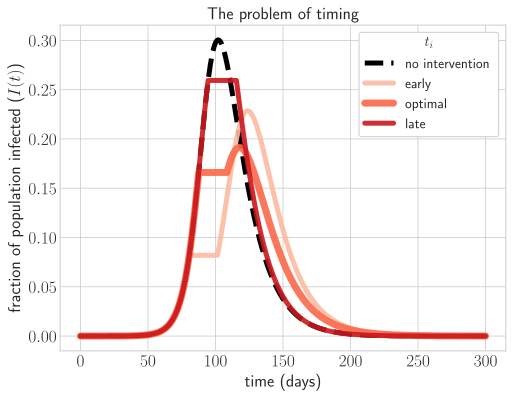

In [12]:
## plot our results

fig, axis = plt.subplots(figsize = (8, 6))

inv_result_plot(raw_results, 
                no_inv, 
                t_is_raw, 
                times, 
                axis = axis)
axis.set_title("The problem of timing")

We see here that while the optimal intervention achieves a dramatic reduction in the height of the peak, mistiming the intervention can be disastrous. Intervening too early does indeed produce a resurgent peak, but it is substantially worse to intervene too late. With a one week late intervention, the $I_\text{max}$ is barely reduced relative to $I_{\max}$ in the absence of any intervention. 

The extreme costs of mistiming derive from the steepness of the exponential growth curve. Intensive time-limited interventions require a large number of infectious individuals to be present if they are to deplete susceptibles effectively. That means that $t_\text{opt}$ occurs near the point of maximally rapid exponential growth.

The problem with this is intuitive: the $I(t)$ curve is extremely steep at $t_\text{opt}$, and so small errors in timing produce large errors in terms of $I(t)$. But the error is also asymmetric: being late is costlier than being early. The early intervention is strongly suboptimal and allows a large resurgence, but that resurgence is still slower and smaller (thanks to susceptible depletion) than the prolonged uncontrolled growth period that permitted by a late intervention.

# A less risky, more robust strategy: continuous control

Time-limited intensive interventions are appealing to policymakers because they are efficient. For COVID-19-like parameters, a dramatic reduction in the peak epidemic incidence $I_{\max}$ can be achieved with only a few weeks' worth of major economic and social impact. It is understandable that the policymakers should wish to optimize in this way. Continuous control measures that act to reduce $\beta$ and thus $\mathcal{R}_0$ for a longer period will clearly less efficient and more costly.

Our analysis reveals a major flaw with this reasoning: time-limited intensive interventions are not robust to mistiming. Let us now consider a continuous control approach that reduces $\beta$ and thus $\mathcal{R}_0$ by 25%. We will first consider the value of that approach in itself, and then see what is achievable if you layer an intensive intervention – whether well-timed or mistimed – on top of the continuous control efforts.

Note that reducing $\beta$ by approximately 25% is feasible if costly in the real world – for instance via banning large gatherings, closing restaurants, nightclubs, schools, and sporting venues – whereas tuning $\beta(t)$ to hold $\mathcal{R}_e$ at 1 is, once again, a steelman: an impossibly perfect version of an intensive intervention.

We first calculate our continuous control results, with and without an additional intensive interaction. We implement a continuous control strategy that reduces $\beta$ by 25% (not in practice that large a reduction). This could represent a number of control strategies that reduce disease-causing contacts an thus decrease $\beta$, for instance [social distancing](http://www.cidrap.umn.edu/sites/default/files/public/php/185/185_factsheet_social_distancing.pdf).


In [13]:
## continuous control parameters
R0_red = 0.75 * R0_raw
gamma_red = gamma_raw
tau_red = tau_raw 


## solve model
t_opt_red = t_opt_integrate(R0_red, 
                            gamma_red, 
                            tau_red, 
                            max_time = 3000)

t_is_red = [t_opt_red - offset, t_opt_red, t_opt_red + offset]

red_results = []
    

for t_i_red in t_is_red:
    no_inv_red, inv = calc_interv_timecourse_t_i(
        R0_red, 
        gamma_red, 
        tau_red, 
        t_i_red, 
        times = times)
    
    red_results.append(inv)

We now plot our results and compare them to the intensive intervention alone.

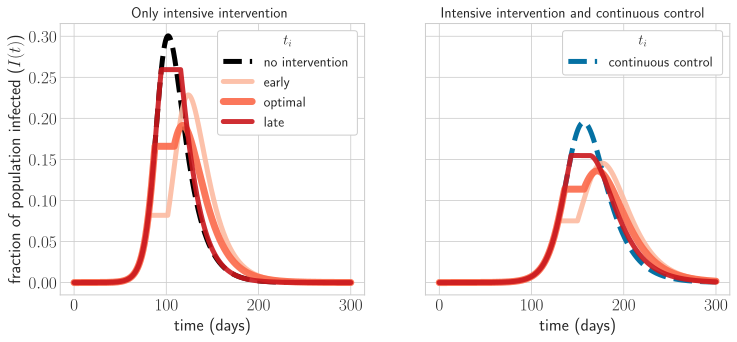

In [14]:
## plot results, and compare 

fig, axes = plt.subplots(ncols = 2, figsize = (12, 5), 
                         sharex = True, 
                         sharey = True)

inv_result_plot(raw_results, 
                no_inv, 
                t_is_raw, 
                times, 
                axis = axes[0])

inv_result_plot(red_results, 
                no_inv_red, 
                t_is_red, 
                times, 
                axis = axes[1], 
                reduced = True,
                legend = False,
                red_inv_color = ourblue)

axes[1].legend(title = "$t_i$", 
               labels = ["continuous control"])

axes[0].set_title("Only intensive intervention", fontsize = 15)
axes[1].set_title("Intensive intervention and continuous control", fontsize = 15)
axes[0].label_outer()
axes[1].label_outer()

In the lefthand plot, we recap our earlier result: being early, or, especially late by even a few days (as plotted: one week) produces a much higher peak. Being a week late is almost as destructive as doing nothing.

With continuous control, the peak is reduced, but at higher social cost. Moreover, for our parameters, it actually achieves less reduction in $I_{\max}$ than could be achieved with an optimal intensive short intervention: the peak of the thick orange curve on the left is in fact lower than the peak of blue dashed curve on the right. But the risk of a mistimed intervention no longer exists.

Moreover, if an intensive intervention remains possible, continuous control also reduces the cost of mistiming that intensive intervention, and makes the intensive intervention strategy itself more robust to mistiming. This occurs for a very simple reason: the steepness of the exponential has been flattened, so timing errors are less devastating.

## Continuous control becomes more appealing as potential timing errors become larger

To assess efficacy of continuous control versus optimally and mistimed interventions, we plot the difference between $I_{\max}$ with an intensive, time-limited intervention and $I_{max}$ with continuous control as a function of how offset (early or late) the intensive intervention is from the optimal time $t_{opt}$.

We first calculate the $I_\text{max}$ values of interest:

In [15]:
## do a sweep across ths offset space
offset = 14
t_is_raw_diff = np.linspace(t_opt_raw - offset, t_opt_raw + offset, 1000)
t_is_red_diff = np.linspace(t_opt_red - offset, t_opt_red + offset, 1000)
offsets = np.linspace(-offset, offset, 1000)

raw_results_diff = []
red_results_diff = []

for t_i_raw in t_is_raw_diff:
    no_inv, inv = calc_interv_timecourse_t_i(
        R0_raw, 
        gamma_raw, 
        tau_raw, 
        t_i_raw, 
        times = times)
    raw_results_diff.append(inv)
    

for t_i_red in t_is_red_diff:
    no_inv_red, inv = calc_interv_timecourse_t_i(
        R0_red, 
        gamma_red, 
        tau_red, 
        t_i_red, 
        times = times)
    red_results_diff.append(inv)
    

And then we plot them:

Text(0, 0.5, '$\\Delta I_{max}$: intensive only minus\ncontinuous only')

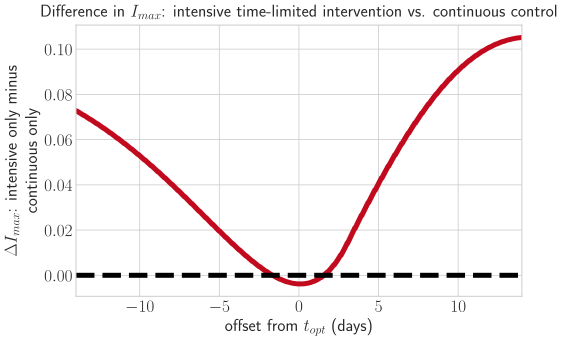

In [16]:
fig, axis = plt.subplots(figsize = (8, 5))

diffs_vs_just_continuous = [np.max(raw[:,1]) - np.max(no_inv_red[:, 1]) 
         for raw in raw_results_diff]
axis.plot(offsets, diffs_vs_just_continuous, lw = 5, color = ourred, label = "only intensive")
axis.axhline(0, ls = "dashed", color = "black")
axis.set_xlim([-14, 14])
axis.set_title("Difference in $I_{max}$: intensive time-limited intervention vs. continuous control")
axis.set_xlabel("offset from $t_{opt}$ (days)")
axis.set_ylabel("$\Delta I_{max}$: intensive only minus\ncontinuous only")


When an intensive intervention is taken sufficiently close to $t_{opt}$, it achieves a lower peak than continuous control (and by assumption this comes at a dramatically reduced social cost relative to continuous control). But relying only on the intensive intervention is not at all robust to timing errors. The intensive intervention produces a substantially higher peak than continuous control (an additional 7% of the total population) if it comes even a week late.

## In addition to its intrinsic benefits, continous control turns intensive intervention into a more robust strategy

As we saw in the timecourse plot, it appears that continuous control, in addition to its own greater robustness, also increases the robustness of any intensive intervention that is layered on top of it. To quantify this, we plot the reduction in $I_{\max}$ achieved by an intensive intervention alone relative to the $I_{\max}$ with no control, and the reduction in $I_{\max}$ achieved by an intensive intervention layered on top of continuous control relative to $I_{\max}$ achieved by continuous control alone.

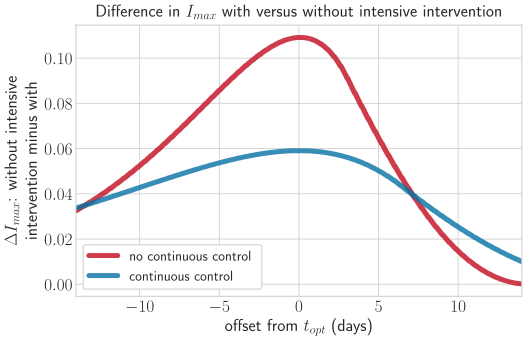

In [17]:
reduction_raw = [np.max(no_inv[:, 1]) - np.max(raw[:, 1]) for raw in raw_results_diff]
reduction_red = [np.max(no_inv_red[:, 1]) - np.max(red[:, 1]) for red in red_results_diff]

fig, axis = plt.subplots(figsize = (8, 5))

axis.plot(offsets, reduction_raw, color = ourred, lw = 5, alpha = 0.8, label = "no continuous control")
axis.plot(offsets, reduction_red, color = ourblue, lw = 5, alpha = 0.8, label = "continuous control")
axis.set_xlim(left = -14, right = 14)
axis.set_title("Difference in $I_{max}$ with versus without intensive intervention")
axis.set_xlabel("offset from $t_{opt}$ (days)")
axis.set_ylabel("$\Delta I_{max}$: without intensive\nintervention minus with")
axis.legend()

How much does the time-limited intensive intervention reduce $I_\max$ versus no intensive intervention, given how far $t_i$ is from $t_{opt}$? We look at this for the intensive only case (red line), where the baseline $I_\max$ is simply $I_\text{peak}$, and for the continuous control case, where the baseline is continuous control without an additional time-limited intensive interaction. For a sufficient degree of mismatch / offset from $t_\text{opt}$, an intensive interaction is in fact more beneficial in terms of raw averted peak cases than it is in the only intensive case. 

Because continuous control alone already reduces the peak relative to doing nothing, this relative measure quantifies *the additional robustness benefit that continuous control affords, above and beyond beyond its peak-lowering benefits.*

## Robustness makes continuous control worth the extra effort
We can visualize the benefit of continuous control's additional robustness to error by quantifying how much lower $I_{\max}$ is with continuous control and a mistimed intensive intervention versus $I_{\max}$ without continuous control and an equally mistimed intensive intervention.

Text(0, 0.5, '$\\Delta I_{max}$: intensive only minus\nintensive w. continuous control')

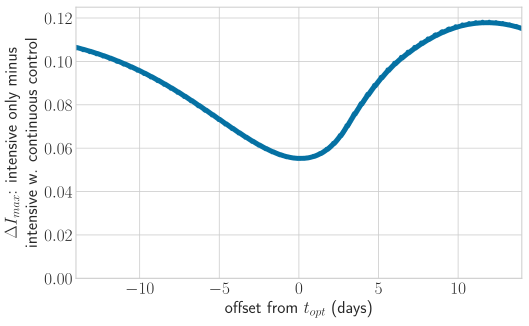

In [18]:
diffs = [np.max(raw[:,1]) - np.max(red[:, 1]) 
         for raw, red, in zip(raw_results_diff, red_results_diff)]

fig, axis = plt.subplots(figsize = (8, 5))
axis.plot(offsets, diffs, lw = 5, color = ourblue)
axis.set_ylim(bottom = 0)
axis.set_xlim(left = -14, right = 14)
axis.set_ylim(bottom = 0, top = 0.125)
axis.set_xlabel("offset from $t_{opt}$ (days)")
axis.set_ylabel("$\Delta I_{max}$: intensive only minus\nintensive w. continuous control")

Here we see the difference in $I_\max$ for time-limited interventions in the presence and absence of continuous control, plotted as the difference between $I_\max$ for only the time-limited intervention and $I_\max$ for the time-limited intervention with continuous control, for a range of possible offsets from $t_\text{opt}$. The optimal time-limited intervention achieves almost as good a result by itself as continuous control *plus* optimal time-limited intervention can do put together. But when there is a mistiming, especially when one is too late, the continuous control outcome is substantially superior.

# Discussion

We have seen here that there is a reason to find time-limited intensive interventions quite attractive in theory. Performed optimally, they can achieve dramatic results in very limited time (our default plotted $\tau$ was only 21 days, or three week). To a policymaker looking to minimize social and economic disruption during disease control, swallowing such a bitter pill but otherwise being able to maintain business as usual might seem extremely attractive.

But we have also seen the costs that hyperoptimization can bring in practice. We made life very easy for our theoretical policymaker. They were given a magic wand that they could use to tune $\beta(t)$ instantaneously and with perfect precision. They were given perfect information on the values of $\mathcal{R}_0$, $\gamma$, and $\tau$, thus allowing them to calculate $t_\text{opt}$ exactly. Their only constraint was that they had to choose exactly when to reach for and start using their magic wand. We show that if they start using the wand even a week too early or too late, consequences are severe – and especially severe if they are late. 

And there are all manner of reasons that our policymaker could miss $t_\text{opt}$ even granting that the underlying epidemiological parameters are perfectly known. For example, one must estimate the current number of cases $I(t)$ in order to know the effective value of $t$ itself, and thus how far away $t_\text{opt}$ is. One must also introduce and enforce control measures – full compliance could easily take longer to achieve than planned, especially given [Hofstadter's law](https://en.wikipedia.org/wiki/Hofstadter%27s_law):

> "Hofstadter's Law: It always takes longer than you expect, even when you take into account Hofstadter's Law." – Douglas Hofstadter

For respiratory viruses, another concern is that $\beta$ is not truly fixed in time even in the absence of intervention. $\beta$ for a respiratory virus tends to exhibit "seasonality": rising in temperate zone winters, falling in temperate zone summers. Influenza is the classic example: the Northern Hemisphere has a winter "flu season". 

There is some reason to suspect that COVID-19 could behave similarly. A policymaker looking at the current COVID-19 epidemic want to keep powder dry for a second peak in the winter, trusting seasonality to take care of flattening the curve during the summer. In future work, we may model this explicitly, but for now we note that anticipating a seasonal drop in $\beta$ that fails to occur and therefore intervening late corresponds qualitatively to intervening later than $t_\text{opt}$. As such, it could be very costly.

# Conclusion

In short, limited-time intensive interventions, performed optimally, are indeed extremely effective and efficient ways to reduce the peak of an epidemic. But they are not robust to implementation error, and that is reason to rethink their use, particularly when armed with incomplete information and combating a novel, poorly understood disease.

# Manuscript 

We are working to turn this blog post into a manuscript, in which we plan to expand this analysis somewhat. We will conduct more parameter sensitivity analysis, consider the costs and robustness (or lack thereof) for other kinds of mistakes in intervention (such as incorrectly estimating $\beta$), and consider the effects of interventions on epidemic final sizes as well as on epidemic peak incidence. In the interim, we welcome comments and critiques.

# Code availability

The Jupyter notebook used to generate this blog post is [available for download in its raw form](http://dylanhmorris.com/files/mistimed_intervention.ipynb), so that the interested reader can reproduce the analysis, vary parameters, et cetera. As we intend to write this work up as a manuscript, however, we are for the moment not licensing the text and code for public reuse and redistribution.

# Acknowledgments

We thank Ada W. Yan, Amandine Gamble, Elizabeth N. Blackmore, James O. Lloyd-Smith, and Joshua B. Plotkin for helpful comments on previous of the post. We thank Simon A. Levin and Corina E. Tarnita for helpful discussions.

# Technical appendix

Here we provide some technical results for the interested reader.

### Theorem: We will intervene no later than when $S(t) = \frac{1}{\mathcal{R}_0} + I(t) \gamma \tau$
Let $S_\text{crit} = \frac{1}{R_0}$ be the critical fraction susceptible at which $\mathcal{R}_e = 1$ (in the absence of intervention). This is where the epidemic will peak if we do not intervene.

We will always intervene while the epidemic is still growing, otherwise $I_{\max}$ will simply be $I_\text{peak}$ which is maximally suboptimal. It follows that $S(t_i) \ge S_\text{crit}$.

Since the epidemic is still growing at $t_i$, $I_i$ is the largest value of $I(t)$ in the window $t = 0$ to $t = t_i$. It follows that $I_\text{max} = \max\Big\{I_i, I_\text{window max}(t_i + \tau)\Big\}$

If we intervene such that $S_i \le S_\text{crit} + I_i \gamma \tau$, then $S(t_i + \tau) < S_\text{crit}$, which implies that $I(t)$ monotonically declines once the intervention is finished, and therefore $I_\text{window max}(t_i + \tau) < I_i$, so $I_\text{max} = I_i$. But the earlier we intervene, the smaller $I_i$ is, so within this range the optimal choice is 

$$S_i = S_\text{crit} + I_i \gamma \tau$$

It is clear that this produces $I_\max = I_i < I_\text{peak}$, which is an improvement.

This establishes the theorem.

### Theorem: among two interventions that end with the same number of infecteds, the intervention that leaves fewer susceptibles (has lower $S_e \ge S_\text{crit}$) is superior for reducing $I_\text{window max}(t_i + \tau)$.

Consider the expression for $I_\text{window max}(t_i + \tau)$. 

$$I_\text{window max}(t_i + \tau) = I_e + S_e - \frac{1}{\mathcal{R}_0} \log(S_e) + \text{const. terms}$$

Suppose intervention $x$ ends with $S_{ex}, I_{e}$ and intervention $y$ with $S_{ey}, I_{e}$, such that $S_{ey} < S_{ex}$. Differentiating shows that, fixing $I_e$, $I_\text{window max}(t_i + \tau)$ is an increasing function of $S_e$ on the interval $S_e \in [S_\text{crit}, 1]$. So since the $I_e$ terms are equal and $S_e \ge S_\text{crit}$, our result must hold.

### Theorem: if an intervention is optimal, $I_\max$ will not occur until after the intervention (That is, if $I_p$ is the maximum value of $I$ during the intervention $I_\max > I_p$).

$I_\max$ cannot occur before the intervention begins, as that implies that the epidemic is already shrinking when the intervention begins and thus will never grow again, regardless of the intervention approach (since $b(t) \le 1$, we cannot force a declining epidemic to grow). But this implies that $I_\max = I_\text{peak}$, which we know from the previous theorem that we can without question improve upon.

Now suppose a strategy $x$ has some largest value $I_{px}$ of $I_x(t)$ during the intervention. Consider a strategy $y$ that takes $b_y(t) = b_x(t)$ except in a window $t - \delta_1 < t < t_{px}$, when we set $b_y(t) = b_x(t) - \delta_2$. By choosing $\delta_1, \delta_2$ small enough for any $\epsilon > 0$, we can ensure $I_{py} < I_{px}$ while keeping $S_{py} - S_{px}$ and $I_{py} - I_{px}$ both $< \epsilon$. Since this only marginally increases $I_\text{window max}(t_i + \tau)$ (as it is a continuous function of $I_e$ and $S_e$, by continuity we can iterate this process until $I_\max$ occurs after the intervention, since we continuously decrease $I_p$ and increase $I_\text{window max}(t_i + \tau)$.

**Corollary:** $S_e > S_\text{crit}$ for any optimal intervention, otherwise $I_p$ would be $I_\max$.

### Technical note: suboptimal interventions and $\beta > \mathcal{R}_0 \gamma$
While an optimal intervention will never reach $S_\text{crit}$, a suboptimal intervention, with $I_i$ too large, might do so. In that case, our strategy for choosing $\beta$ to maximize the rate of susceptible depletion would involve actually _raising_ $\beta$ above what its value would be in the absence of intervention (since $\mathcal{R}_0 \gamma < \frac{\gamma}{S(t)}$ when $S(t) < \frac{1}{\mathcal{R}_0} = S_\text{crit}$). This is a bit illogical, and might not even be feasible (and breaks the assumptions the prove optimal).

For this reason, we assume that $\beta(t)$ during an intervention is given by the smaller of the raw $\beta = \mathcal{R}_0 \gamma$ and $\beta(t) = \frac{\gamma}{S(t)}$. In other words, intervention necessarily ceases when $S_\text{crit}$ is reached, even if $t < t < t_i + \tau$.